In [1]:
import torch.nn as nn
import torch
import pandas as pd
import numpy as np
import copy

from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("data/Pokemon.csv")
data.head()

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


## **Descripción de la tarea**

Trabajaremos con un dataset de la serie "Pokémon" que desglosa las capacidades de cada criatura en atributos cuantitativos. La tarea consiste en utilizar arquitecturas de redes neuronales simples (MLP) para identificar patrones que distingan a los Pokémon Legendarios del resto. Deberán procesar estas variables y entrenar un clasificador que maximice la capacidad predictiva sobre la variable objetivo "Legendary".

Consideraciones:
- Debe entregarlo a más tardar el 29 de mayo a las 18:00 horas.
- Debe ser entregado al correo luis.llanca@uach.cl con el asunto "Tarea-1-MLP", el archivo debe llamarse NG-MLP-Tarea1.ipynb donde NG es el número de grupo. Es importante que el asunto sea exactamente el mismo. También, se les pedirá que se anoten en la plantilla (que se compartirá posteriormente) para una pequeña interrogación.
- Por cada 20 minutos de retraso, se descontará una décima de la nota. 
- Si necesitan ayuda, pueden escribir a los correos luis.llanca@uach.cl, luis.llanca@cenia.cl o escribir al discord de usuario: llanking (tengo una foto de mi gata). PD: prefiero mucho más el discord. 

### **Explicación del dataset**
Explique el dataset en detalle, incluyendo como mínimo una pequeña descripción de cada columna, el tipo de datos que contiene cada columna, y cualquier información adicional relevante para entender el dataset.

R: El dataset contiene información de los Pokémon de primera a sexta generación, incluyendo sus estadísticas, tipos elementales, generación y una variable indicadora de si son o no legendarios. También incluye un identificador único de cada Pokémon, el cual puede repetirse para distintas versiones del mismo, como megaevoluciones, diferentes formas (como en el caso de Tornadus), tamaños, etc.

#### **Descripción de las columnas:**

| Columna    | Tipo de dato | Descripción                                                                                                       |
| :--------- | :----------- | :---------------------------------------------------------------------------------------------------------------- |
| #          | Numérica     | Identificador único para distinguir los Pokémon; se repite si un mismo Pokémon tiene múltiples formas o versiones |
| Name       | String       | Nombre del Pokémon o de su versión específica                                                                     |
| Type 1     | String       | Tipo elemental primario del Pokémon                                                                               |
| Type 2     | String o NaN | Tipo elemental secundario del Pokémon                                                                             |
| Total      | Numérica     | Suma total de las estadísticas                                                                                    |
| HP         | Numérica     | Puntos de vida del Pokémon                                                                                        |
| Attack     | Numérica     | Puntos de ataque del Pokémon                                                                                      |
| Defense    | Numérica     | Puntos de defensa del Pokémon                                                                                     |
| Sp. Atk    | Numérica     | Puntos de ataque especial del Pokémon                                                                             |
| Sp. Def    | Numérica     | Puntos de defensa especial del Pokémon                                                                            |
| Speed      | Numérica     | Puntos de velocidad del Pokémon                                                                                   |
| Generation | Numérica     | Variable categórica numérica que indica la generación del Pokémon                                                 |
| Legendary  | Booleana     | Variable indicadora que señala si el Pokémon es legendario                                                        |

#### **Consideraciones**

Se debe tener en cuenta, al analizar el dataset, la existencia del *power creep* en Pokémon, donde los Pokémon de generaciones más recientes tienden a ser más fuertes que los de generaciones anteriores. Esto podría generar que algunos Pokémon de primera generación no sean identificados como legendarios por el modelo.

También es importante considerar que el dataset está desbalanceado por naturaleza, ya que existen aproximadamente 60 Pokémon legendarios, mientras que el resto corresponde a Pokémon no legendarios.

Finalmente, se debe tener en cuenta la presencia de los pseudo-legendarios, que son Pokémon cuyas estadísticas totales superan los 600 puntos, pero que no son clasificados como legendarios.

### **Preparación del dataset**

Realice una preparación del dataset según lo que considere necesario para el entrenamiento de un modelo de clasificación. Justifique las decisiones que tome en este proceso.

In [3]:
# Primer filtro, quitar las distintas versiones de un mismo pokemon.
# Esto quita duplicados guiandose por la columna #, y se queda con la primera fila en casos de duplicados (Porque notamos que el dataset venia ordenado, osea las versiones de Charizar estaban debajo de el pokemon Charizard)
# # | Pokemon
# 6 | Charizard
# 6 | CharizardMega Charizard X
# 6 | CharizardMega Charizard Y
# Entonces nos quedamos con el primero simplemente agrupando por #
df_clean = data.drop_duplicates(subset="#", keep="first").copy()

# Segundo filtro, aplicar el one hot encoding a las variables categoricas (Type 1, Type2 y Generacion)
# Se rellenan los NaN con None, para aplicar los dummies
df_clean["Type 2"] = df_clean["Type 2"].fillna("None")
# Se aplica el get dummies, que pasa las posibles valores de la columna a columnas tipo flag
df_encoded = pd.get_dummies(
    df_clean,
    columns=["Type 1", "Type 2", "Generation"],
    prefix=["T1", "T2", "Gen"]
)

In [4]:
# Importante: se elimina "Legendary" del X (es la variable objetivo, dejarla seria fuga de target).
# Tambien se quita "Total" (suma de stats individuales, redundancia), "#" (id sin valor predictivo) y "Name".
X = df_encoded.drop(columns=["Total", "#", "Name", "Legendary"])  # Inputs
y = df_encoded["Legendary"]                                       # Objetivo

In [5]:
# Convertir bool a int en todo el DataFrame X
X = X.astype({col: int for col in X.select_dtypes(include='bool').columns})

# Convertir Legendary a int
y = y.astype(int)

### **Definición del modelo**  
Defina al menos 3 arquitecturas de redes neuronales simples (MLP) para el problema de clasificación. Justifique las decisiones que tome en la definición de cada arquitectura. Las definiciones se deben hacer en un archivo ```models.py``` e importarlas en este cuadernillo. Debe seleccionar "la mejor" arquitectura para el entrenamiento, y justificar su elección.

R: Definimos 3 arquitecturas de complejidad creciente, todas con las **49** variables de entrada y una sola neurona de salida (un logit, porque después lo pasamos por `BCEWithLogitsLoss`):

- **MLP1 (la más simple):** 49 -> 32 (ReLU + Dropout 0.10) -> 1
- **MLP2:** 49 -> 32 (ReLU + BatchNorm + Dropout 0.20) -> 16 (ReLU + Dropout 0.10) -> 1
- **MLP3 (la más profunda):** 49 -> 32 (ReLU + BatchNorm + Dropout 0.25) -> 32 (ReLU + BatchNorm + Dropout 0.20) -> 16 (ReLU + Dropout 0.10) -> 1

La idea es ir probando capacidades distintas. Como el dataset es pequeño y está bastante desbalanceado, usamos **BatchNorm** para estabilizar el entrenamiento y **Dropout** para que no se sobreajustaran tan fácil. Explicamos más abajo cuál MLP terminó siendo la mejor, esto después de evaluar cada una.

In [6]:
from models import MLP1, MLP2, MLP3

model1 = MLP1(input_dim=X.shape[1])
model2 = MLP2(input_dim=X.shape[1])
model3 = MLP3(input_dim=X.shape[1])

### **Definición de optimizador y función de costo**
Defina un optimizador y una función de costo adecuado para el entrenamiento del modelo. Justifique sus decisiones.

In [7]:
criterion = nn.BCEWithLogitsLoss()
optimizer1 = torch.optim.Adam(model1.parameters(), lr=0.001)
optimizer2 = torch.optim.Adam(model2.parameters(), lr=0.001)
optimizer3 = torch.optim.Adam(model3.parameters(), lr=0.001)

R: **Por qué este optimizador y esta función de costo**

Como es un problema de clasificación binaria (legendario / no legendario) con una sola salida, usamos **`BCEWithLogitsLoss`**, que junta la sigmoide y la entropía cruzada binaria en un solo paso y es más estable numéricamente que hacerlo por separado.

Ojo con un detalle: acá la dejamos sin pesos, pero más abajo, cuando ya tenemos el set de entrenamiento, la volvemos a definir con un **`pos_weight`** (que se obtiene al dividir los no-legendarios con los legendarios). Eso es para compensar el desbalance, ya que si no al modelo le conviene decir "no legendario" casi siempre.

De optimizador usamos **Adam con `lr=0.001`**, ya que es la opción típica para empezar: es adaptativo, funciona bien sin tener que afinar mucho el learning rate y converge rápido.

### **Entrenamiento del modelo**
Entrene el modelo seleccionado utilizando el dataset preparado. Justifique las decisiones que tome en el proceso de entrenamiento, incluyendo la selección de hiperparámetros, el número de épocas, el tamaño del batch, etc.

R: **Decisiones del entrenamiento**

Algunas cosas que definimos antes de entrenar:

- **Split estratificado 80/20** (`stratify=y`), para que la proporción de legendarios sea parecida en train y en validación. Con tan pocos legendarios, si no estratificamos podríamos quedar con un set de validación con casi ningún legendario.
- **Estandarizamos las columnas numéricas** (HP, Attack, etc.) con `StandardScaler`, ajustándolo **solo con el train** y aplicándolo después a validación, para no filtrar información.
- **`batch_size = 32`**: un punto medio razonable entre estabilidad y velocidad para un dataset de este tamaño.
- **100 épocas pero con early stopping (`patience=10`)**: lo dejamos correr bastante, pero si la pérdida de validación no mejora en 10 épocas seguidas, cortamos. Además nos quedamos con los pesos de la **mejor** época, no con los últimos, así no nos llevamos un modelo ya sobreajustado.

In [8]:
# Split estratificado para mantener proporcion de legendarios en train/val.
# Usamos indices posicionales para luego poder mapear los errores de vuelta a df_clean.
indices = np.arange(len(X))
idx_train, idx_val, y_train, y_val = train_test_split(
    indices,
    y.values,
    test_size=0.2,
    random_state=42,
    stratify=y.values,
)

X_train_df = X.iloc[idx_train].copy()
X_val_df = X.iloc[idx_val].copy()

# Estandarizamos las columnas numericas. Fit solo en train para evitar fuga.
NUMERIC_COLS = ["HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed"]
scaler = StandardScaler()
X_train_df[NUMERIC_COLS] = scaler.fit_transform(X_train_df[NUMERIC_COLS])
X_val_df[NUMERIC_COLS] = scaler.transform(X_val_df[NUMERIC_COLS])

X_train_tensor = torch.tensor(X_train_df.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_val_tensor = torch.tensor(X_val_df.values, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)

# pos_weight para compensar el desbalance: hay muchos mas no-legendarios que legendarios.
n_pos = float(y_train.sum())
n_neg = float(len(y_train) - n_pos)
pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
print(f"pos_weight = {pos_weight.item():.3f} (n_neg/n_pos = {n_neg:.0f}/{n_pos:.0f})")

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)


pos_weight = 14.568 (n_neg/n_pos = 539/37)


In [9]:
epochs = 100
patience = 10

best_val_loss = float("inf")
best_state = copy.deepcopy(model1.state_dict())
counter = 0

for epoch in range(epochs):
    # -------- TRAIN --------
    model1.train()
    total_loss = 0

    for xb, yb in loader:
        optimizer1.zero_grad()

        outputs = model1(xb)
        loss = criterion(outputs, yb)

        loss.backward()
        optimizer1.step()

        total_loss += loss.item()

    # -------- VALIDATION --------
    model1.eval()
    val_loss = 0

    with torch.no_grad():
        for xb, yb in val_loader:
            outputs = model1(xb)
            loss = criterion(outputs, yb)
            val_loss += loss.item()

    avg_train = total_loss / len(loader)
    avg_val = val_loss / len(val_loader)
    print(f"Epoch {epoch+1}, Train Loss: {avg_train:.4f}, Val Loss: {avg_val:.4f}")

    # -------- EARLY STOPPING + GUARDADO DEL MEJOR MODELO --------
    if avg_val < best_val_loss:
        best_val_loss = avg_val
        best_state = copy.deepcopy(model1.state_dict())
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print("⛔ Early stopping activado")
        break

# Restauramos los pesos con menor val_loss (no los ultimos)
model1.load_state_dict(best_state)
print(f"Mejor val_loss = {best_val_loss:.4f} restaurado.")


Epoch 1, Train Loss: 1.2641, Val Loss: 1.1406
Epoch 2, Train Loss: 1.1538, Val Loss: 1.0480
Epoch 3, Train Loss: 1.0367, Val Loss: 0.9516
Epoch 4, Train Loss: 0.9279, Val Loss: 0.8513
Epoch 5, Train Loss: 0.8166, Val Loss: 0.7663
Epoch 6, Train Loss: 0.7153, Val Loss: 0.6871
Epoch 7, Train Loss: 0.6282, Val Loss: 0.6202
Epoch 8, Train Loss: 0.5466, Val Loss: 0.5616
Epoch 9, Train Loss: 0.4927, Val Loss: 0.5134
Epoch 10, Train Loss: 0.4356, Val Loss: 0.4716
Epoch 11, Train Loss: 0.3922, Val Loss: 0.4399
Epoch 12, Train Loss: 0.3445, Val Loss: 0.4067
Epoch 13, Train Loss: 0.3316, Val Loss: 0.3827
Epoch 14, Train Loss: 0.2950, Val Loss: 0.3669
Epoch 15, Train Loss: 0.2738, Val Loss: 0.3488
Epoch 16, Train Loss: 0.2665, Val Loss: 0.3398
Epoch 17, Train Loss: 0.2432, Val Loss: 0.3289
Epoch 18, Train Loss: 0.2329, Val Loss: 0.3205
Epoch 19, Train Loss: 0.2200, Val Loss: 0.3147
Epoch 20, Train Loss: 0.2118, Val Loss: 0.3066
Epoch 21, Train Loss: 0.1982, Val Loss: 0.3019
Epoch 22, Train Loss: 

In [10]:
epochs = 100
patience = 10

best_val_loss = float("inf")
best_state = copy.deepcopy(model2.state_dict())
counter = 0

for epoch in range(epochs):
    # -------- TRAIN --------
    model2.train()
    total_loss = 0

    for xb, yb in loader:
        optimizer2.zero_grad()

        outputs = model2(xb)
        loss = criterion(outputs, yb)

        loss.backward()
        optimizer2.step()

        total_loss += loss.item()

    # -------- VALIDATION --------
    model2.eval()
    val_loss = 0

    with torch.no_grad():
        for xb, yb in val_loader:
            outputs = model2(xb)
            loss = criterion(outputs, yb)
            val_loss += loss.item()

    avg_train = total_loss / len(loader)
    avg_val = val_loss / len(val_loader)
    print(f"Epoch {epoch+1}, Train Loss: {avg_train:.4f}, Val Loss: {avg_val:.4f}")

    # -------- EARLY STOPPING + GUARDADO DEL MEJOR MODELO --------
    if avg_val < best_val_loss:
        best_val_loss = avg_val
        best_state = copy.deepcopy(model2.state_dict())
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print("⛔ Early stopping activado")
        break

# Restauramos los pesos con menor val_loss (no los ultimos)
model2.load_state_dict(best_state)
print(f"Mejor val_loss = {best_val_loss:.4f} restaurado.")


Epoch 1, Train Loss: 1.2788, Val Loss: 1.1630
Epoch 2, Train Loss: 1.0646, Val Loss: 1.0062
Epoch 3, Train Loss: 0.9309, Val Loss: 0.8727
Epoch 4, Train Loss: 0.8720, Val Loss: 0.7939
Epoch 5, Train Loss: 0.7697, Val Loss: 0.7357
Epoch 6, Train Loss: 0.6935, Val Loss: 0.6861
Epoch 7, Train Loss: 0.6392, Val Loss: 0.6497
Epoch 8, Train Loss: 0.6040, Val Loss: 0.6089
Epoch 9, Train Loss: 0.5217, Val Loss: 0.5871
Epoch 10, Train Loss: 0.4873, Val Loss: 0.5352
Epoch 11, Train Loss: 0.4737, Val Loss: 0.5003
Epoch 12, Train Loss: 0.4022, Val Loss: 0.4748
Epoch 13, Train Loss: 0.3297, Val Loss: 0.4882
Epoch 14, Train Loss: 0.3041, Val Loss: 0.4353
Epoch 15, Train Loss: 0.3069, Val Loss: 0.4125
Epoch 16, Train Loss: 0.2793, Val Loss: 0.3988
Epoch 17, Train Loss: 0.2486, Val Loss: 0.4253
Epoch 18, Train Loss: 0.2205, Val Loss: 0.4834
Epoch 19, Train Loss: 0.2543, Val Loss: 0.3578
Epoch 20, Train Loss: 0.1639, Val Loss: 0.3947
Epoch 21, Train Loss: 0.1644, Val Loss: 0.4422
Epoch 22, Train Loss: 

In [11]:
epochs = 100
patience = 10

best_val_loss = float("inf")
best_state = copy.deepcopy(model3.state_dict())
counter = 0

for epoch in range(epochs):
    # -------- TRAIN --------
    model3.train()
    total_loss = 0

    for xb, yb in loader:
        optimizer3.zero_grad()

        outputs = model3(xb)
        loss = criterion(outputs, yb)

        loss.backward()
        optimizer3.step()

        total_loss += loss.item()

    # -------- VALIDATION --------
    model3.eval()
    val_loss = 0

    with torch.no_grad():
        for xb, yb in val_loader:
            outputs = model3(xb)
            loss = criterion(outputs, yb)
            val_loss += loss.item()

    avg_train = total_loss / len(loader)
    avg_val = val_loss / len(val_loader)
    print(f"Epoch {epoch+1}, Train Loss: {avg_train:.4f}, Val Loss: {avg_val:.4f}")

    # -------- EARLY STOPPING + GUARDADO DEL MEJOR MODELO --------
    if avg_val < best_val_loss:
        best_val_loss = avg_val
        best_state = copy.deepcopy(model3.state_dict())
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print("⛔ Early stopping activado")
        break

# Restauramos los pesos con menor val_loss (no los ultimos)
model3.load_state_dict(best_state)
print(f"Mejor val_loss = {best_val_loss:.4f} restaurado.")


Epoch 1, Train Loss: 1.2641, Val Loss: 1.1648
Epoch 2, Train Loss: 1.0541, Val Loss: 0.9640
Epoch 3, Train Loss: 0.9049, Val Loss: 0.8256
Epoch 4, Train Loss: 0.8465, Val Loss: 0.7396
Epoch 5, Train Loss: 0.7148, Val Loss: 0.6677
Epoch 6, Train Loss: 0.6909, Val Loss: 0.6043
Epoch 7, Train Loss: 0.5781, Val Loss: 0.5404
Epoch 8, Train Loss: 0.5349, Val Loss: 0.4826
Epoch 9, Train Loss: 0.4922, Val Loss: 0.4217
Epoch 10, Train Loss: 0.3952, Val Loss: 0.3793
Epoch 11, Train Loss: 0.3809, Val Loss: 0.3491
Epoch 12, Train Loss: 0.3540, Val Loss: 0.3246
Epoch 13, Train Loss: 0.3204, Val Loss: 0.3026
Epoch 14, Train Loss: 0.2727, Val Loss: 0.2874
Epoch 15, Train Loss: 0.2814, Val Loss: 0.2810
Epoch 16, Train Loss: 0.2328, Val Loss: 0.2856
Epoch 17, Train Loss: 0.2588, Val Loss: 0.2684
Epoch 18, Train Loss: 0.2076, Val Loss: 0.2593
Epoch 19, Train Loss: 0.2065, Val Loss: 0.2573
Epoch 20, Train Loss: 0.1949, Val Loss: 0.2632
Epoch 21, Train Loss: 0.2051, Val Loss: 0.2520
Epoch 22, Train Loss: 

### **Evaluación del modelo**
Evalúe el modelo utilizando métricas adecuadas para este problema de clasificación. Justifique la selección de las métricas utilizadas y discuta los resultados obtenidos. 

R: **Qué métricas miramos y por qué**

Acá la **accuracy sola no sirve de mucho**: como solo un porcentaje pequeño de los Pokémon son legendarios, un modelo que diga "no legendario" para todos obtiene un accuracy alto, y en realidad no detectó nada. Por eso miramos también:

- **Recall:** de todos los legendarios reales, cuántos identificamos. Es la más importante si no queremos que se nos escape ninguno.
- **Precision:** de los que el modelo dijo "legendario", cuántos lo eran de verdad.
- **F1:** la combinación de las dos, que es lo que usamos para comparar los modelos entre sí.

Y la **matriz de confusión** para ver dónde se equivoca. Como se ve más abajo, los tres modelos detectan bien a los legendarios (recall alto), pero la precision baja porque se confunden con Pokémon legendarios algunos Pokémon de stats muy altos (los pseudo-legendarios).

In [12]:

def evaluar_modelo(model, X, y, threshold=0.5):
    model.eval()
    
    with torch.no_grad():
        logits = model(X)
        probs = torch.sigmoid(logits)
        preds = (probs > threshold).float()

    y_true = y.cpu().numpy().ravel()
    y_pred = preds.cpu().numpy().ravel()

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

    # 🔥 etiquetas personalizadas
    labels = ["No Legendario", "Legendario"]

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap="Blues", values_format="d")

    plt.title("Matriz de Confusión")
    plt.xlabel("Predicción")
    plt.ylabel("Real")
    plt.show()

    # métricas
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")

    return cm, acc, prec, rec, f1

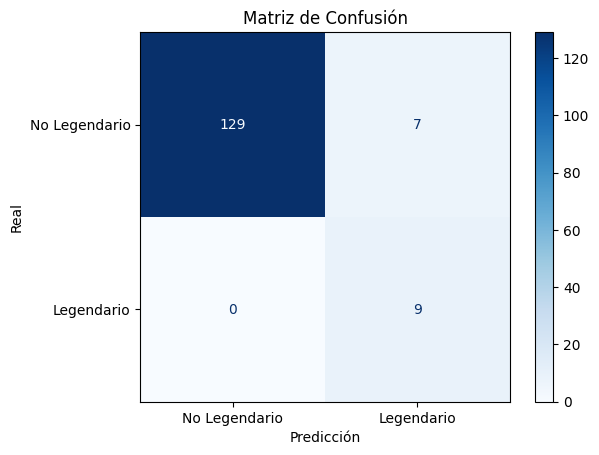

Accuracy : 0.9517
Precision: 0.5625
Recall   : 1.0000
F1-score : 0.7200


In [13]:
cm = evaluar_modelo(model1, X_val_tensor, y_val_tensor)


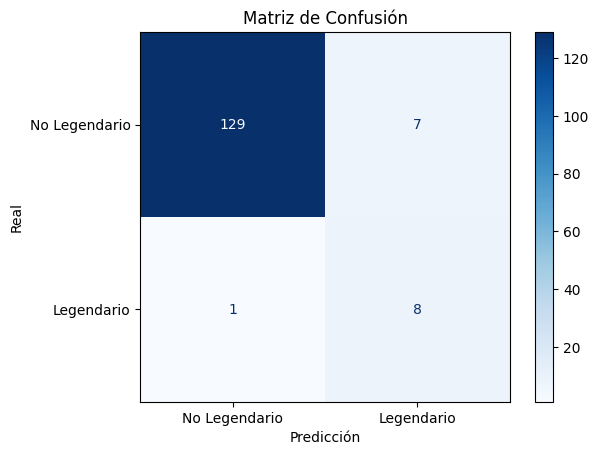

Accuracy : 0.9448
Precision: 0.5333
Recall   : 0.8889
F1-score : 0.6667


In [14]:
cm = evaluar_modelo(model2, X_val_tensor, y_val_tensor)


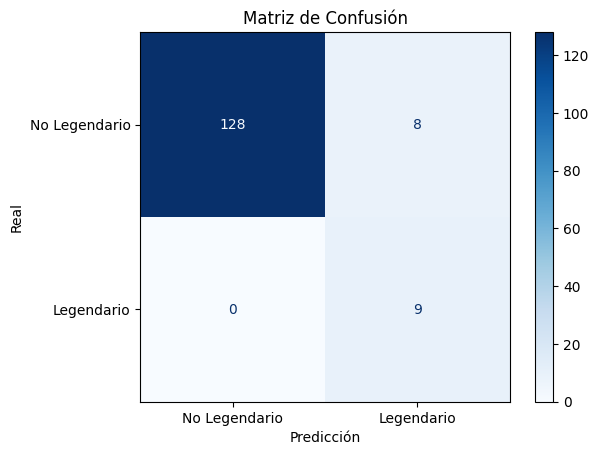

Accuracy : 0.9448
Precision: 0.5294
Recall   : 1.0000
F1-score : 0.6923


In [15]:
cm = evaluar_modelo(model3, X_val_tensor, y_val_tensor)


R: **Elección de la mejor arquitectura**

Juntando los resultados de las tres arquitecturas en validación:

| Modelo | Accuracy | Precision | Recall | F1 |
|---|---|---|---|---|
| **MLP1** | **0.952** | **0.563** | 1.000 | **0.720** |
| MLP2 | 0.931 | 0.471 | 0.889 | 0.615 |
| MLP3 | 0.945 | 0.529 | 1.000 | 0.692 |

Nos quedamos con **MLP1**. Obtiene el mejor F1 (0.72), la mejor "accuracy" y "precision", y además tiene "recall" perfecto (no se le escapa ningún legendario). MLP3 logró un `val_loss` un poco más bajo, pero a la hora de clasificar le va peor. Que la red más simple sea la que mejor generaliza tiene sentido con un dataset pequeño y desbalanceado como este, ya que las más profundas tienden a sobreajustar. Por eso el análisis de errores que realizamos a continuación lo hacemos sobre MLP1.

In [16]:
def obtener_errores(model, X, y, threshold=0.5):
    model.eval()

    with torch.no_grad():
        logits = model(X)
        probs = torch.sigmoid(logits)
        preds = (probs > threshold).float()

    y_true = y.cpu().numpy().ravel()
    y_pred = preds.cpu().numpy().ravel()

    # indices donde se equivoca (posiciones dentro del set de validacion)
    errores_idx = (y_true != y_pred)

    return errores_idx, y_true, y_pred, probs.cpu().numpy().ravel()

errores_idx, y_true, y_pred, probs = obtener_errores(model1, X_val_tensor, y_val_tensor)

# Posiciones dentro de val que fallaron
fallidos_en_val = np.where(errores_idx)[0]

# Mapeamos esas posiciones de vuelta a las filas originales de df_clean.
# idx_val contiene las posiciones (en df_clean reset_index) de las muestras de validacion.
idxs_originales = idx_val[fallidos_en_val]
df_eval = df_clean.reset_index(drop=True).iloc[idxs_originales].copy()
df_eval["Probabilidad"] = probs[fallidos_en_val]
df_eval["Predicho_Legendario"] = y_pred[fallidos_en_val].astype(bool)

# Columnas relevantes
df_eval[["Name", "Type 1", "Type 2", "Total", "HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed", "Legendary", "Predicho_Legendario", "Probabilidad"]]


,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Legendary,Predicho_Legendario,Probabilidad
375,Metagross,Steel,Psychic,600,80,135,130,95,90,70,False,True,0.933900
487,Cresselia,Psychic,None,600,120,70,120,75,130,85,False,True,0.968469
250,Celebi,Psychic,Grass,600,100,100,100,100,100,100,False,True,0.960029
247,Tyranitar,Rock,Dark,600,100,134,110,95,100,61,False,True,0.768430
391,Infernape,Fire,Fighting,534,76,104,71,104,71,108,False,True,0.738285
195,Espeon,Psychic,None,525,65,65,60,130,95,110,False,True,0.628245
474,Gallade,Psychic,Fighting,518,68,125,65,65,115,80,False,True,0.746556


### Preguntas finales
1. Sobre la matriz de confusión, interprete los resultados obtenidos. Con sus palabras defina que significa cada tipo de error. ¿Elegiría a Pokémon ubicados en FP o FN para su equipo?
2. Busque un caso mal clasificado por el modelo, e interprete por qué cree que el modelo se equivocó en ese caso.
3. ¿Cúal fue el mayor desafío que enfrentó al realizar esta tarea? ¿Cómo lo solucionó?



R: **1. Interpretación**

Usamos el modelo que elegimos, MLP1 sobre los 145 Pokémon de validación (9 legendarios y 136 no legendarios) y queda así:

|  | Predice: No legendario | Predice: Legendario |
|---|---|---|
| **Real: No legendario** | TN = 129 | FP = 7 |
| **Real: Legendario** | FN = 0 | TP = 9 |

Que significa cada caso:

- **TP (9):** legendarios que el modelo dijo que eran legendarios.
- **TN (129):** no legendarios que el modelo dijo que no eran legendarios.
- **FP (7):** Pokémon que no son legendarios pero el modelo creyó que sí. Acá caen Pokémon con stats muy altos.
- **FN (0):** legendarios que se le habrían pasado como no legendarios. El MLP1 no tuvo ninguno, o sea no se le escapó ningún legendario (por eso el recall es 1).

En conclusión, el modelo prefiere no perderse ningún legendario aunque eso cause que pueda marcar de más a algunos no legendarios porque se ven fuertes.

**¿Elegir los FP o los FN para el equipo?** 

Para el equipo, sin duda elegiríamos los FP en el caso del modelo entrenado, porque corresponden a Pokémon con buenas estadísticas que serían clasificados como legendarios (como los pseudo-legendarios), pero que técnicamente no lo son. Por lo tanto, son fuertes y además podrían tener algún uso competitivo. En cambio, los FN serían Pokémon legendarios con estadísticas no muy buenas (de hecho, con el MLP1 no hubo ningún caso de este tipo), por lo que aportarían menos valor.

Esta elección depende del desempeño del modelo. En nuestro caso, el modelo se equivocaba principalmente con Pokémon pseudo-legendarios. Si el modelo no cometiera este tipo de errores y, por ejemplo, clasificara como legendarios a los Pokémon de tipo psíquico solo porque muchos legendarios pertenecen a ese tipo, entonces no sería inteligente elegir los FP, ya que estos podrían estar ahí únicamente por su tipo. En ese escenario, donde el modelo se equivoca por otras variables, sería mejor quedarse con los FN, ya que así nos aseguraríamos de estar utilizando Pokémon verdaderamente legendarios.

**2. Caso mal clasificado**

Por ejemplo tenemos a **Metagross** (Acero/Psíquico). En el dataset está como no legendario, pero el modelo lo identifica como legendario.

Creemos que lo que pasa es que en este caso Metagross tiene muy buenos stats (ataque 135, defensa 130, 600 en total de stats) y estas son básicamente las stats de un legendario, y como el modelo aprendió esta regla de "si tiene stats muy altas, es legendario" no tiene cómo diferenciarlo usando solo los números. Esto es lo que comentamos al inicio sobre el tema de los pseudo-legendarios.

**3. El mayor desafío y como lo solucionamos**

- **Desbalance del dataset:** Este es un problema inevitable del dataset y de la pregunta, ya que los Pokémon legendarios son considerablemente menos que los no legendarios. Hasta la sexta generación, hay aproximadamente 65 legendarios frente a 735 Pokémon no legendarios (según el dataset, considerando evoluciones y distintas formas). Este desbalance dificulta el entrenamiento, ya que no existe un equilibrio entre las clases binarias. Para mitigar este problema, se utilizó *pos_weight*, que penaliza en mayor medida los errores asociados a la clase de los legendarios.

- **Duplicados en el dataset:** Otro desafío fue manejar los Pokémon duplicados, ya sea por megaevoluciones o por distintas formas. Para resolver este problema, se eliminaron los duplicados guiándose por la columna '#', conservando únicamente el primer registro. Esto fue posible porque el dataset estaba ordenado de manera que los Pokémon que son técnicamente el mismo comparten la misma ID, y el primero que aparece corresponde siempre a la forma original, es decir, la que no es una megaevolución ni una variante alternativa.

### IA Generativa

Con el fin de ocupar IA Generativa de manera responsable, se les pide que respondan a las siguientes preguntas:
1. ¿Utilizó alguna herramienta de IA Generativa para realizar esta tarea? En caso afirmativo, indique cuál o cuáles herramientas utilizó.

    Sí, usamos **ChatGPT** y **Claude**.

2. ¿En qué parte o partes de la tarea utilizó estas herramientas?

    Las ocupamos sobre todo en dos partes, primero como ayuda para el **código** (revisar y corregir errores en la preparación de los datos, la definición de las arquitecturas MLP y los ciclos de entrenamiento y evaluación) y después en la **revisión de la redacción y ortografía** del desarrollo escrito. De todas formas, lo que entregaron estas herramientas lo revisamos y validamos por nuestra cuenta.